## MODELO MACHINE LEARNING - ADOPCIONES

##### Características del modelo:

- Modelo supervisado de clasificación binaria: Emplearé LogisticRegression para realizar todo el proceso de modelado

- Dataset: Obtenido de Kaggle --> Registro de las adopciones de un refugio de animales; más información en este enlace: [Datos obtenidos en Kaggle](https://www.kaggle.com/datasets/rabieelkharoua/predict-pet-adoption-status-dataset).

- Atención: Según la información observada en la página web, este dataset es antiguo, por lo que es posible que no sea aplicable a la vida real. Sin embargo, es útil para realizar un modelo y hacer predicciones hipotéticas.

***

### Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn import model_selection

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

***

### Carga de los datos

In [2]:
df_adopciones = pd.read_csv("data/pet_adoption_data.csv")

***

### Visualización general de los datos

In [3]:
df_adopciones.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0


In [4]:
df_adopciones.describe()

,PetID,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
count,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
mean,1503.000000,92.279522,15.705776,0.701046,0.196313,43.974091,249.142003,0.301943,0.328351
std,579.515315,52.148363,8.327749,0.457914,0.397307,25.740253,142.887040,0.459215,0.469730
min,500.000000,1.000000,1.018198,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1001.500000,48.000000,8.730396,0.000000,0.000000,21.000000,127.000000,0.000000,0.000000
50%,1503.000000,94.000000,15.925416,1.000000,0.000000,45.000000,242.000000,0.000000,0.000000
75%,2004.500000,138.000000,22.737180,1.000000,0.000000,66.000000,375.000000,1.000000,1.000000
max,2506.000000,179.000000,29.995628,1.000000,1.000000,89.000000,499.000000,1.000000,1.000000


In [5]:
df_adopciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   object 
 2   Breed               2007 non-null   object 
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   object 
 5   Size                2007 non-null   object 
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 204.0+ KB


### Presentación de las variables

| Variable | Descripción | Tipo |
| -------- | ----------- | ---- |
| PetID    | Número de identificación del animal | Numérica |
| PetType  | Tipo de animal | Categórica |
| Breed    | Raza | Categórica |
| AgeMonths | Edad del animal en meses (cambio a años para mejorar comprensión) | Numérica |
| Color | Color del pelaje | Categórica |
| Size | Tamaño del animal | Categórica |
| WeightKg | Peso del animal en kilogramos | Numérica |
| Vaccinated | Animal vacunado (1) o no (0) | Binaria = Categórica |
| HealthCondition | Animal sano (0) o necesita medicación (1) | Binaria = Categórica |
| TimeInShelterDays | Tiempo que el animal ha estado en el refugio en días | Numérica |
| AdoptionFee | "Cuota" OBLIGATORIA de los gastos de mantenimiento del animal al adoptarlo | Numérica |
| PreviousOwner | El animal tenía dueño previamente (1) o no (0) | Binaria = Categórica | 
| AdoptionLikellhood | Adopción (1) o no (0) | Target |

Dado que el objetivo de realizar este modelo es predecir si los animales serán adoptados o no en función de otras características (features aún no definidas), se considerará:

- Target --> AdoptionLikelihood
- Features --> Resto de variables

### Preparación y limpieza de datos

- En el caso de la variable PetID (Identificador del animal) no es necesaria para la predicción. Por lo que esa variable va a ser eliminada.  
- Creo que para una mejor interpretación y comprensión de los datos en la presentación, es necesario cambiar las edades de meses a años.  
- Para manipular mejor la variable target, voy a cambiarle el nombre de "AdoptionLikelihood" a "target"



In [6]:
# Elimino PetID:

df_adopciones = df_adopciones.drop(columns = ["PetID"], axis = 1)

In [7]:
# Transformación de edad de meses a años:

df_adopciones["AgeYears"] = round(df_adopciones["AgeMonths"]/12, 2)

In [8]:
df_adopciones = df_adopciones.drop(columns = ["AgeMonths"], axis = 1)

In [9]:
# Cambio de nombre de target

df_adopciones = df_adopciones.rename(columns = {"AdoptionLikelihood": "target"})

In [10]:
df_adopciones.duplicated().value_counts()

False    2007
Name: count, dtype: int64

##### Datos limpios:

- Columna PetID eliminada
- Transformación de edad de meses a años
- Cambio de nombre de la variable target
- Dataset sin valores duplicados

El dataset original no tiene valores nulos, por lo que no tengo que realizar ninguna imputación de valores

***

### Visualización de variable target

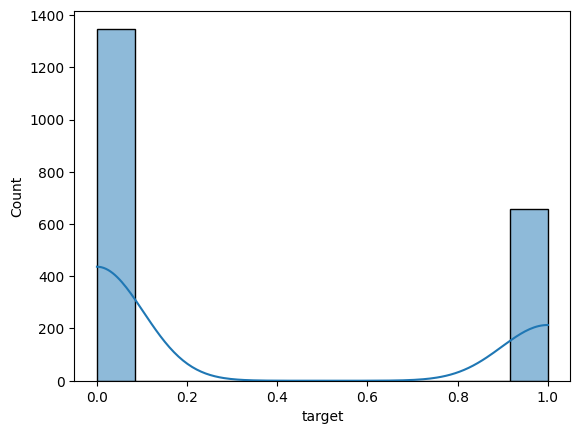

In [11]:
sns.histplot(data = df_adopciones, x = "target", kde = True)
plt.show();

- Variable binaria
- No adoptados --> 0 
- Adoptados --> 1

Distribución: Se observa una mayor proporción de animales no adoptados frente a los que han sido adoptados (desbalanceada)

***

### División del dataset en train y test

In [12]:
X = df_adopciones.drop(["target"], axis = 1)
y = df_adopciones["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

***

### MiniEDA

##### Matriz de correlación

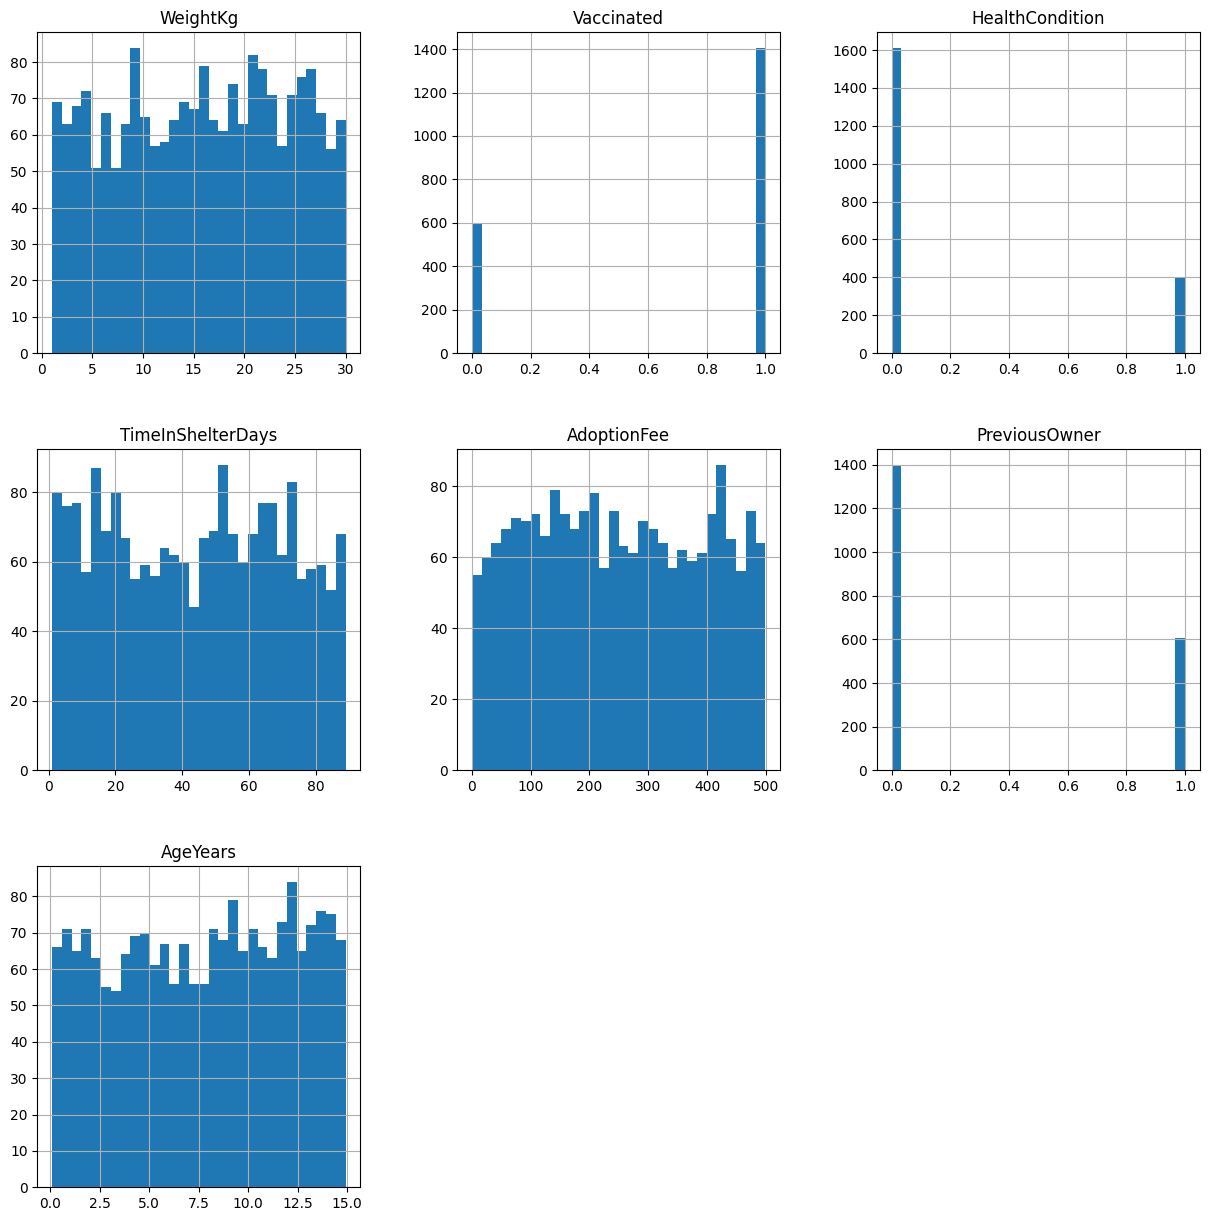

In [13]:
X.hist(bins = 30, figsize = (15, 15))
plt.show()

En primer lugar, vo a transformar las variables categóricas tipo string con *get_dummies* para obtener 0s y 1s, valores asimilables por el modelo.

A continuación voy a realizar la correlación de las variables numéricas con la variable objetivo (target), añadiendo la visualización.

##### Categóricas a tratar:

| Variable | Descripción | Tipo |
| -------- | ----------- | ---- |
| PetType  | Tipo de animal | Categórica |
| Breed    | Raza | Categórica |
| Color | Color del pelaje | Categórica |
| Size | Tamaño del animal | Categórica |

In [14]:
# Transformación de las variables:

X_train_bck = X_train.copy()
X_train = pd.get_dummies(X_train, columns = ["PetType", "Breed", "Color", "Size"], dtype = int)
X_train

,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AgeYears,PetType_Bird,PetType_Cat,PetType_Dog,...,Breed_Rabbit,Breed_Siamese,Color_Black,Color_Brown,Color_Gray,Color_Orange,Color_White,Size_Large,Size_Medium,Size_Small
916,15.083291,1,0,74,419,0,5.67,0,0,1,...,0,0,1,0,0,0,0,0,1,0
261,24.471717,0,0,44,408,1,14.33,0,1,0,...,0,1,0,1,0,0,0,0,1,0
607,10.893330,0,0,43,373,0,14.08,0,0,0,...,1,0,0,0,0,1,0,1,0,0
1331,2.863329,0,1,50,342,0,11.25,0,0,0,...,1,0,0,0,1,0,0,1,0,0
240,26.926209,1,0,73,55,0,14.08,0,0,0,...,1,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,22.924123,1,0,49,49,0,13.75,0,1,0,...,0,1,1,0,0,0,0,1,0,0
1294,8.366900,1,0,72,412,0,6.75,1,0,0,...,0,0,0,0,1,0,0,1,0,0
860,28.031744,1,0,31,246,1,1.58,1,0,0,...,0,0,0,0,1,0,0,0,0,1
1459,13.871824,1,0,87,419,1,12.92,1,0,0,...,0,0,0,0,1,0,0,1,0,0


##### Proceso de Matriz de correlación

In [15]:
numericas = ["WeightKg", "TimeInShelterDays", "AdoptionFee", "AgeYears"]

In [16]:
X_train_num = X_train[numericas]

In [17]:
X_train_bck = X_train.copy()

In [18]:
X_train_num

,WeightKg,TimeInShelterDays,AdoptionFee,AgeYears
916,15.083291,74,419,5.67
261,24.471717,44,408,14.33
607,10.893330,43,373,14.08
1331,2.863329,50,342,11.25
240,26.926209,73,55,14.08
...,...,...,...,...
1130,22.924123,49,49,13.75
1294,8.366900,72,412,6.75
860,28.031744,31,246,1.58
1459,13.871824,87,419,12.92


In [19]:
correlacion = X_train_num.copy()
correlacion["target"] = y_train.values

corr = correlacion.corr()[["target"]].sort_values(by = "target",ascending = False)

In [20]:
corr

,target
target,1.000000
TimeInShelterDays,0.014699
WeightKg,0.008203
AdoptionFee,0.007398
AgeYears,-0.193840


<Axes: >

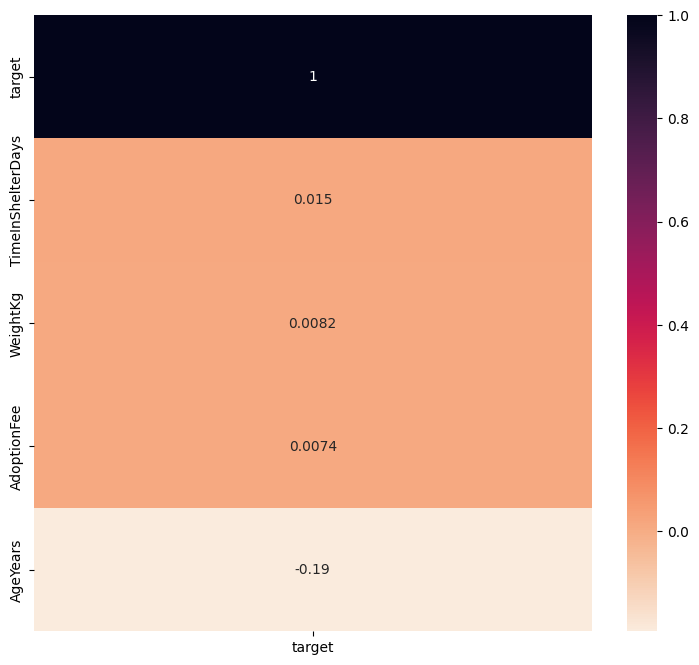

In [21]:
plt.figure(figsize = (9,8))
sns.heatmap(corr, annot = True, cmap = "rocket_r")

A pesar de los coeficientes de correlación de las variables numéricas (individualmente) con la variable objetivo, tienen una correlación muy baja, esta situación puede asemejarse a la realidad del mundo de las adopciones: Las adopciones no dependen de características aisladas, sino de la combinación con otras características (raza, tamaño, salud...). Por ello, voy a mantener todas las variables para realizar el modelo. Puede ser, que las variables de manera individual no aporten nada a la hora de realizar la predicción, pero combinadas, puedan aportar información útil.

***

### Modelo

##### Preparación previa al modelo

En este caso, la variable objetivo es una variable binaria. Al observarla al principio del notebook, se aprecia desbalance entre la no adopción (0, más frecuente) con respecto a las adopcion (1). Por ello, voy a comprobar el porcentaje de desbalanceo que existe, para aplicarle el balanceo al crear el modelo.

In [22]:
# Comprobación del porcentaje de desbalanceo entre categorías:
y_train.value_counts(normalize = True)

target
0    0.671651
1    0.328349
Name: proportion, dtype: float64

Con el porcentaje obtenido, se observa un claro desbalance entre categorías. Esto, en cuanto al modelo, puede provocar que éste se incline hacia la categoría mayoritaria, no aprendiendo nada útil sobre las adopciones. Por ello, aplico class_weight = balanced, para paliar esta desigualdad entre clases.

##### Construcción + entrenamiento del modelo

In [23]:
log_reg = LogisticRegression (max_iter = 5000, class_weight = "balanced")
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

##### Interpretación de los pesos

In [36]:
print(log_reg.coef_, "\n")
print(log_reg.intercept_, "\n")
print(log_reg.classes_)

[[ 1.35931440e-03  2.71843925e+00 -2.85123768e+00  3.93280326e-04
  -6.65557528e-04 -9.41115038e-02 -1.56091579e-01 -2.10705280e-01
  -3.27360200e-01  7.69764252e-01 -2.38190119e-01 -6.90889928e-01
   1.83486294e+00 -2.10705280e-01 -4.38822292e-01 -3.74208756e-01
  -2.38190119e-01  1.11462092e-01  1.27947821e-01 -2.25670850e-02
  -1.18052006e-01  9.74406524e-02 -9.12607292e-02 -1.13193465e+00
   2.02842221e+00 -9.02978910e-01]] 

[-0.69956455] 

[0 1]


- log_reg.coef_ : Los coeficientes en positivo, indican aumento la probabilidad de adopción, frente a los negativos, que la disminuyen.

- log_reg.intercept_ : Al obtener un valor negativo, el modelo tiende a predecir la "no adopción" dado que es la clase dominante de la variable.

- log_reg.classes_ : Orden en el que el modelo está trabajando. Relacionado con la variable target, por eso [0 1]

In [39]:
# Visualización más clara de los coeficientes:

coef= pd.Series(log_reg.coef_[0], index = X_train.columns)

coef_df = pd.DataFrame(coef.sort_values(ascending=False), columns=['Coefficient'])
coef_df

,Coefficient
Vaccinated,2.718439
Size_Medium,2.028422
Breed_Labrador,1.834863
PetType_Dog,0.769764
Color_Black,0.127948
Breed_Siamese,0.111462
Color_Orange,0.097441
WeightKg,0.001359
TimeInShelterDays,0.000393
AdoptionFee,-0.000666


***

### Feature Importance